# Lab 2 - Task 1: Frequency-Based Baseline

Baseline con frequenze delle API call e Logistic Regression.

## Funzioni

**Checkpoint/cache.** Su Colab gli artefatti del Task 1 vengono salvati in `Google Drive/MyDrive/lab2/artifacts/task-1`.
Con `FORCE_RETRAIN = False`, se il modello esiste gia su Drive Optuna viene saltato e il modello viene ricaricato.


In [37]:
import json
import subprocess
import sys
from collections import Counter
from pathlib import Path
from urllib.request import urlretrieve

try:
    import optuna
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna", "-q"])
    import optuna

import joblib
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [38]:
RANDOM_STATE = 42
RAW_BASE_URL = "https://raw.githubusercontent.com/MagicThunder02/lab2/main"
TRAIN_PATH = Path("train.json")
TEST_PATH = Path("test.json")
FIGURE_DIR = Path("figures/task-1")
FORCE_RETRAIN = False
USE_GOOGLE_DRIVE_ARTIFACTS = True
DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/lab2")
LOCAL_ARTIFACT_DIR = Path("artifacts/task-1")


def is_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False


def get_artifact_dir():
    if USE_GOOGLE_DRIVE_ARTIFACTS and is_colab():
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
        artifact_dir = DRIVE_PROJECT_DIR / "artifacts/task-1"
    else:
        artifact_dir = LOCAL_ARTIFACT_DIR
    artifact_dir.mkdir(parents=True, exist_ok=True)
    return artifact_dir


ARTIFACT_DIR = get_artifact_dir()
print(f"Task 1 artifacts directory: {ARTIFACT_DIR}")


def raw_url_for(path):
    return f"{RAW_BASE_URL}/{Path(path).as_posix()}"


def try_download_from_github(path):
    path = Path(path)
    if path.exists():
        return True
    url = raw_url_for(path)
    try:
        path.parent.mkdir(parents=True, exist_ok=True)
        print(f"Downloading {path.as_posix()} from {url}")
        urlretrieve(url, path)
        return True
    except Exception:
        if path.exists():
            path.unlink()
        return False


def ensure_data_file(path):
    path = Path(path)
    if path.exists() or try_download_from_github(path):
        return path

    try:
        from google.colab import files
    except ImportError as exc:
        raise FileNotFoundError(
            f"{path.name} not found locally and could not be downloaded from {raw_url_for(path)}."
        ) from exc

    print(f"Could not download {path.name}. Upload it manually in Colab.")
    uploaded = files.upload()
    if path.name not in uploaded:
        raise FileNotFoundError(f"Uploaded files do not include {path.name}.")
    return path


def load_dataset(path):
    path = ensure_data_file(path)
    with path.open(encoding="utf-8") as f:
        data = json.load(f)
    X = [row["api_call_sequence"] for row in data]
    y = np.array([row["is_malware"] for row in data], dtype=int)
    return X, y


def vocabulary(sequences):
    return set(api for seq in sequences for api in seq)


def sequence_length_summary(sequences):
    lengths = np.array([len(seq) for seq in sequences])
    return {
        "n_samples": len(sequences),
        "min_len": int(lengths.min()),
        "median_len": float(np.median(lengths)),
        "mean_len": float(lengths.mean()),
        "max_len": int(lengths.max()),
    }


def dataset_overview(X_train, y_train, X_test, y_test):
    rows = []
    for split, X, y in [("train", X_train, y_train), ("test", X_test, y_test)]:
        label_counts = Counter(y)
        row = sequence_length_summary(X)
        row.update({
            "split": split,
            "goodware_0": label_counts.get(0, 0),
            "malware_1": label_counts.get(1, 0),
            "malware_%": 100 * label_counts.get(1, 0) / len(y),
            "unique_api_calls": len(vocabulary(X)),
        })
        rows.append(row)
    cols = ["split", "n_samples", "goodware_0", "malware_1", "malware_%", "min_len", "median_len", "mean_len", "max_len", "unique_api_calls"]
    return pd.DataFrame(rows)[cols].round(3)


def vocabulary_report(X_train, X_test):
    train_vocab = vocabulary(X_train)
    test_vocab = vocabulary(X_test)
    only_test = sorted(test_vocab - train_vocab)
    only_train = sorted(train_vocab - test_vocab)
    summary = pd.DataFrame([{
        "train_vocab_size": len(train_vocab),
        "test_vocab_size": len(test_vocab),
        "intersection": len(train_vocab & test_vocab),
        "only_in_test_count": len(only_test),
        "only_in_train_count": len(only_train),
    }])
    return summary, only_test, only_train


def sequences_to_text(sequences):
    return [" ".join(seq) for seq in sequences]


def build_frequency_matrices(X_train, X_test):
    train_vocab = sorted(vocabulary(X_train))
    vectorizer = CountVectorizer(
        analyzer="word",
        tokenizer=str.split,
        preprocessor=None,
        token_pattern=None,
        vocabulary=train_vocab,
        lowercase=False,
    )
    X_train_freq = vectorizer.fit_transform(sequences_to_text(X_train))
    X_test_freq = vectorizer.transform(sequences_to_text(X_test))
    feature_names = vectorizer.get_feature_names_out()
    return X_train_freq, X_test_freq, feature_names, vectorizer


def sparsity_report(X_train_freq, X_test_freq):
    rows = []
    for split, matrix in [("train", X_train_freq), ("test", X_test_freq)]:
        nnz_per_row = matrix.getnnz(axis=1)
        n_features = matrix.shape[1]
        rows.append({
            "split": split,
            "shape": f"{matrix.shape[0]} x {matrix.shape[1]}",
            "avg_non_zero_per_row": nnz_per_row.mean(),
            "min_non_zero": nnz_per_row.min(),
            "median_non_zero": np.median(nnz_per_row),
            "max_non_zero": nnz_per_row.max(),
            "non_zero_ratio": nnz_per_row.mean() / n_features,
            "zero_ratio": 1 - (nnz_per_row.mean() / n_features),
        })
    return pd.DataFrame(rows).round(4)


def train_logistic_regression(X_train_freq, y_train, n_trials=30):
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    def objective(trial):
        params = {
            "C": trial.suggest_float("C", 1e-3, 100.0, log=True),
            "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
            "penalty": trial.suggest_categorical("penalty", ["l1", "l2"]),
        }
        model = LogisticRegression(
            solver="liblinear",
            max_iter=2000,
            random_state=RANDOM_STATE,
            **params,
        )
        scores = cross_val_score(model, X_train_freq, y_train, scoring="f1_macro", cv=cv, n_jobs=-1)
        return scores.mean()

    sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best_params = study.best_params
    model = LogisticRegression(
        solver="liblinear",
        max_iter=2000,
        random_state=RANDOM_STATE,
        **best_params,
    )
    model.fit(X_train_freq, y_train)

    trials = study.trials_dataframe(attrs=("number", "value", "params", "state"))
    trials = trials.sort_values("value", ascending=False).reset_index(drop=True)
    return model, best_params, study.best_value, trials


def artifact_paths(artifact_dir=ARTIFACT_DIR):
    artifact_dir = Path(artifact_dir)
    return {
        "model": artifact_dir / "logistic_regression.joblib",
        "trials": artifact_dir / "optuna_trials.csv",
        "summary": artifact_dir / "training_summary.json",
        "results": artifact_dir / "results.json",
    }


def save_training_artifacts(model, best_params, best_cv_score, optuna_trials, artifact_dir=ARTIFACT_DIR):
    paths = artifact_paths(artifact_dir)
    Path(artifact_dir).mkdir(parents=True, exist_ok=True)
    joblib.dump(model, paths["model"])
    optuna_trials.to_csv(paths["trials"], index=False)
    summary = {
        "best_params": best_params,
        "best_cv_score": float(best_cv_score),
        "model_type": "LogisticRegression",
        "cv": "StratifiedKFold(n_splits=5, shuffle=True)",
        "scoring": "f1_macro",
    }
    with paths["summary"].open("w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)


def load_training_artifacts(artifact_dir=ARTIFACT_DIR):
    paths = artifact_paths(artifact_dir)
    required = [paths["model"], paths["trials"], paths["summary"]]
    for path in required:
        if not path.exists():
            return None

    model = joblib.load(paths["model"])
    optuna_trials = pd.read_csv(paths["trials"])
    with paths["summary"].open(encoding="utf-8") as f:
        summary = json.load(f)
    return model, summary["best_params"], summary["best_cv_score"], optuna_trials


def train_or_load_logistic_regression(X_train_freq, y_train, force_retrain=FORCE_RETRAIN, n_trials=30):
    if not force_retrain:
        cached = load_training_artifacts()
        if cached is not None:
            print("Loaded Logistic Regression artifacts from cache.")
            return cached

    print("Training Logistic Regression with Optuna.")
    model, best_params, best_cv_score, optuna_trials = train_logistic_regression(
        X_train_freq, y_train, n_trials=n_trials
    )
    save_training_artifacts(model, best_params, best_cv_score, optuna_trials)
    return model, best_params, best_cv_score, optuna_trials


def evaluate_classifier(model, X_test_freq, y_test):
    y_pred = model.predict(X_test_freq)
    y_score = model.predict_proba(X_test_freq)[:, 1]
    metrics = pd.DataFrame([{
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_goodware_0": f1_score(y_test, y_pred, pos_label=0, zero_division=0),
        "f1_malware_1": f1_score(y_test, y_pred, pos_label=1, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
    }]).round(4)
    cm = pd.DataFrame(
        confusion_matrix(y_test, y_pred, labels=[0, 1]),
        index=["true_goodware_0", "true_malware_1"],
        columns=["pred_goodware_0", "pred_malware_1"],
    )
    report = pd.DataFrame(classification_report(y_test, y_pred, labels=[0, 1], target_names=["goodware_0", "malware_1"], output_dict=True, zero_division=0)).T.round(4)
    return metrics, cm, report


def save_evaluation_artifacts(metrics, cm, report, artifact_dir=ARTIFACT_DIR):
    paths = artifact_paths(artifact_dir)
    Path(artifact_dir).mkdir(parents=True, exist_ok=True)
    results = {
        "metrics": metrics.to_dict(orient="records"),
        "confusion_matrix": cm.to_dict(),
        "classification_report": report.to_dict(),
    }
    with paths["results"].open("w", encoding="utf-8") as f:
        json.dump(results, f, indent=2)


def api_presence_in_test_only(X_test, only_test_apis):
    counts = Counter(api for seq in X_test for api in seq if api in only_test_apis)
    rows = [{"api_call": api, "test_frequency": counts[api]} for api in only_test_apis]
    return pd.DataFrame(rows)


def save_confusion_matrix_plot(cm, figure_dir=FIGURE_DIR, filename="confusion_matrix", title="Logistic Regression Confusion Matrix"):
    import matplotlib.pyplot as plt

    figure_dir = Path(figure_dir)
    figure_dir.mkdir(parents=True, exist_ok=True)
    matrix = cm.to_numpy()
    labels = ["Goodware (0)", "Malware (1)"]
    fig, ax = plt.subplots(figsize=(5.2, 4.4))
    image = ax.imshow(matrix, interpolation="nearest", cmap="Blues")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        ylabel="True label",
        xlabel="Predicted label",
        title=title,
    )
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right", rotation_mode="anchor")
    threshold = matrix.max() / 2
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(
                j,
                i,
                f"{matrix[i, j]:d}",
                ha="center",
                va="center",
                color="white" if matrix[i, j] > threshold else "black",
                fontsize=12,
            )
    fig.tight_layout()
    fig.savefig(figure_dir / f"{filename}.pdf", dpi=300, bbox_inches="tight")
    fig.savefig(figure_dir / f"{filename}.png", dpi=300, bbox_inches="tight")
    return fig


Mounted at /content/drive
Task 1 artifacts directory: /content/drive/MyDrive/lab2/artifacts/task-1


## Output per rispondere al Task 1

In [39]:
X_train, y_train = load_dataset(TRAIN_PATH)
X_test, y_test = load_dataset(TEST_PATH)

overview = dataset_overview(X_train, y_train, X_test, y_test)
display(overview)

,split,n_samples,goodware_0,malware_1,malware_%,min_len,median_len,mean_len,max_len,unique_api_calls
0,train,16325,611,15714,96.257,60,75.0,75.031,90,258
1,test,6505,243,6262,96.264,70,87.0,86.331,100,232


In [40]:
vocab_summary, only_test_apis, only_train_apis = vocabulary_report(X_train, X_test)
display(vocab_summary)
print("API call presenti solo nel test:")
print(only_test_apis)
display(api_presence_in_test_only(X_test, only_test_apis))

,train_vocab_size,test_vocab_size,intersection,only_in_test_count,only_in_train_count
0,258,232,229,3,29


API call presenti solo nel test:
['ControlService', 'NtDeleteKey', 'WSASocketA']


,api_call,test_frequency
0,ControlService,1
1,NtDeleteKey,1
2,WSASocketA,1


In [41]:
X_train_freq, X_test_freq, feature_names, vectorizer = build_frequency_matrices(X_train, X_test)
print(f"Feature usate: vocabolario del train ({len(feature_names)} colonne).")
print("Le API presenti solo nel test vengono ignorate perch? non hanno una colonna appresa dal train.")
display(sparsity_report(X_train_freq, X_test_freq))

Feature usate: vocabolario del train (258 colonne).
Le API presenti solo nel test vengono ignorate perch? non hanno una colonna appresa dal train.


,split,shape,avg_non_zero_per_row,min_non_zero,median_non_zero,max_non_zero,non_zero_ratio,zero_ratio
0,train,16325 x 258,21.9471,2,22.0,41,0.0851,0.9149
1,test,6505 x 258,24.2782,2,26.0,45,0.0941,0.9059


In [42]:
model, best_params, best_cv_score, optuna_trials = train_or_load_logistic_regression(X_train_freq, y_train)
print("Migliori iperparametri:", best_params)
print(f"Miglior F1 macro medio con Optuna + 5-fold CV: {best_cv_score:.4f}")
display(optuna_trials.head(10).round(4))

Training Logistic Regression with Optuna.
Migliori iperparametri: {'C': 41.318506569741785, 'class_weight': None, 'penalty': 'l2'}
Miglior F1 macro medio con Optuna + 5-fold CV: 0.7180


,number,value,params_C,params_class_weight,params_penalty,state
0,22,0.7180,41.3185,None,l2,COMPLETE
1,12,0.7175,85.5240,None,l2,COMPLETE
2,25,0.7174,4.5520,None,l2,COMPLETE
3,16,0.7173,32.9516,None,l2,COMPLETE
4,23,0.7173,27.7671,None,l2,COMPLETE
5,24,0.7170,10.8431,None,l2,COMPLETE
6,10,0.7170,69.9642,None,l2,COMPLETE
7,13,0.7165,97.3840,None,l2,COMPLETE
8,21,0.7165,98.0968,None,l2,COMPLETE
9,18,0.7165,22.9692,None,l2,COMPLETE


Metriche finali sul test set


,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_goodware_0,f1_malware_1,roc_auc
0,0.9688,0.6654,0.818,0.6654,0.7154,0.4469,0.9839,0.9028


Matrice di confusione


,pred_goodware_0,pred_malware_1
true_goodware_0,82,161
true_malware_1,42,6220


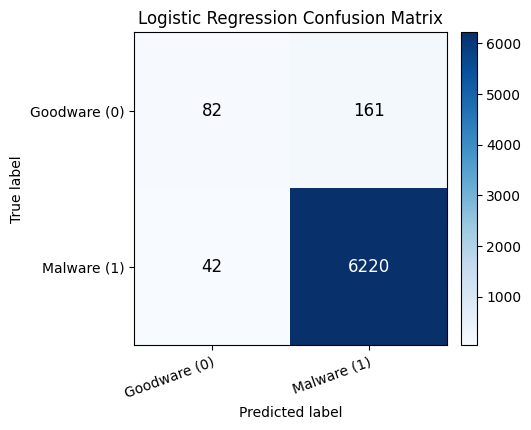

Classification report


,precision,recall,f1-score,support
goodware_0,0.6613,0.3374,0.4469,243.0000
malware_1,0.9748,0.9933,0.9839,6262.0000
accuracy,0.9688,0.9688,0.9688,0.9688
macro avg,0.8180,0.6654,0.7154,6505.0000
weighted avg,0.9631,0.9688,0.9639,6505.0000


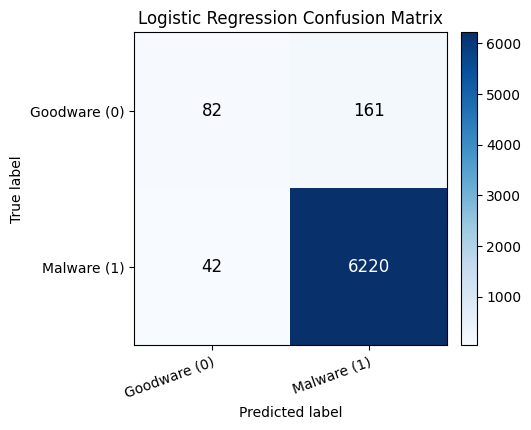

In [43]:
metrics, cm, report = evaluate_classifier(model, X_test_freq, y_test)
save_evaluation_artifacts(metrics, cm, report)
print("Metriche finali sul test set")
display(metrics)
print("Matrice di confusione")
display(cm)
fig = save_confusion_matrix_plot(cm)
display(fig)
print("Classification report")
display(report)

In [44]:
answers = [
    ["Vocabolario", f"Train: {len(vocabulary(X_train))} API uniche. Test: {len(vocabulary(X_test))} API uniche. Solo nel test: {len(only_test_apis)} ({', '.join(only_test_apis)})."],
    ["Costruzione test dataframe", "Uso sempre il vocabolario del train per train e test. Le API solo nel test sono out-of-vocabulary e vengono ignorate, evitando leakage dal test."],
    ["Sparsita", "Ogni riga ha 258 feature. La tabella sopra mostra gli elementi non-zero medi e il rapporto rispetto al numero di feature."],
    ["Ordine", "No. Il dataframe frequency-based conserva solo quante volte compare ogni API call, non la posizione: non sappiamo piu quale API sia arrivata prima."],
    ["Classifier", f"Logistic Regression. Ho scelto C, class_weight e penalty con Optuna + 5-fold CV sul train, ottimizzando F1 macro. Parametri finali: {best_params}."],
    ["Qualita finale", "La performance e buona se accuracy/F1 malware sono alti, ma va letta insieme a balanced accuracy e F1 goodware perche il dataset e fortemente sbilanciato verso malware."],
]
display(pd.DataFrame(answers, columns=["Domanda", "Risposta sintetica"]))

,Domanda,Risposta sintetica
0,Vocabolario,Train: 258 API uniche. Test: 232 API uniche. S...
1,Costruzione test dataframe,Uso sempre il vocabolario del train per train ...
2,Sparsita,Ogni riga ha 258 feature. La tabella sopra mos...
3,Ordine,No. Il dataframe frequency-based conserva solo...
4,Classifier,"Logistic Regression. Ho scelto C, class_weight..."
5,Qualita finale,La performance e buona se accuracy/F1 malware ...
